# 🌾 AgriSmart — NB4: Inference + Export GeoTIFF

**Objectif :** Appliquer le modèle U-Net entraîné sur l'image complète de Béja
(2500×2000 pixels) et exporter la carte de segmentation en GeoTIFF géoréférencé.

**Pourquoi ce notebook ?**
Le modèle a été entraîné sur des patches 128×128.
Pour inférer sur l'image entière (trop grande pour entrer d'un coup en GPU),
on utilise une **fenêtre glissante** (sliding window) avec recouvrement,
puis on fusionne les prédictions par **vote majoritaire** aux zones de overlap.

**Output :** GeoTIFF compatible QGIS + visualisations PNG + CSV statistiques
(conforme rapport section 8.2 étape 4)

---
## 📦 Part 1 : Setup

In [12]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [13]:
!pip install segmentation_models_pytorch
import torch
import numpy as np
import matplotlib.pyplot as plt
import rasterio
from rasterio.enums import Resampling
import segmentation_models_pytorch as smp
import pandas as pd
from pathlib import Path
import gc, warnings
warnings.filterwarnings('ignore')

# ─── CHEMINS ───────────────────────────────────────────────────────────────
TIFF_PATH  = '/content/drive/MyDrive/GEE_Exports/S2_Beja_2025.tif'
TEMP_DIR   = Path('/content/drive/MyDrive/temp_indices_agrismart')
MODEL_PATH = Path('/content/drive/MyDrive/models/best_unet_beja.pth')
OUTPUT_DIR = Path('/content/drive/MyDrive/agrismart_outputs')
OUTPUT_DIR.mkdir(exist_ok=True)

# ─── PARAMÈTRES ────────────────────────────────────────────────────────────
PATCH_SIZE = 128
STRIDE     = 64
DOWNSAMPLE = 2
N_CLASSES  = 6
N_CHANNELS = 9

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'🖥️  Device : {device}')

def clear_mem():
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

print('✅ Setup OK')

🖥️  Device : cpu
✅ Setup OK


---
## 📂 Part 2 : Chargement image + indices

In [14]:
print('📥 Chargement image Béja...')
with rasterio.open(TIFF_PATH) as src:
    meta = src.meta.copy()
    data = src.read(
        out_shape=(src.count, src.height // DOWNSAMPLE, src.width // DOWNSAMPLE),
        resampling=Resampling.average
    ).transpose(1, 2, 0)

    # Mettre à jour meta pour la résolution downsamplée
    from rasterio.transform import from_bounds
    bounds = src.bounds
    H_ds, W_ds = data.shape[:2]
    meta.update({
        'height': H_ds, 'width': W_ds, 'count': 1, 'dtype': 'uint8',
        'transform': from_bounds(bounds.left, bounds.bottom,
                                 bounds.right, bounds.top, W_ds, H_ds)
    })

blue  = data[:,:,0].astype(np.float32) / 10000
green = data[:,:,1].astype(np.float32) / 10000
red   = data[:,:,2].astype(np.float32) / 10000
nir   = data[:,:,3].astype(np.float32) / 10000
del data; clear_mem()

H, W = blue.shape
print(f'✅ Image chargée : {W}×{H} pixels')

def load_idx(name):
    return np.load(TEMP_DIR / f'{name}.npy').astype(np.float32)

ndvi = load_idx('ndvi'); evi  = load_idx('evi')
savi = load_idx('savi'); ndmi = load_idx('ndmi')
ndwi = load_idx('ndwi')

print('✅ Indices chargés')

📥 Chargement image Béja...
✅ Image chargée : 5365×4619 pixels
✅ Indices chargés


---
## 🔧 Part 3 : Stack + Normalisation

In [15]:
print('📐 Normalisation Z-score...')
feature_stack = np.dstack([blue, green, red, nir, ndvi, evi, savi, ndmi, ndwi])
del blue, green, red, nir, ndvi, evi, savi, ndmi, ndwi; clear_mem()

for b in range(feature_stack.shape[2]):
    band = feature_stack[:,:,b]
    mask = band != 0
    if mask.sum() > 0:
        mu    = band[mask].mean()
        sigma = band[mask].std() + 1e-8
        feature_stack[:,:,b] = np.clip((band - mu) / sigma, -3, 3)

feature_stack = np.nan_to_num(feature_stack, nan=0.0, posinf=3.0, neginf=-3.0)
print(f'NaN check : {np.isnan(feature_stack).sum()} ← doit être 0')

print(f'✅ Stack normalisé : {feature_stack.shape}')

📐 Normalisation Z-score...
NaN check : 0 ← doit être 0
✅ Stack normalisé : (4619, 5365, 9)


---
## 🔄 Part 4 : Chargement modèle + Inference sliding window

**Stratégie sliding window avec vote par probabilités :**
- On accumule les probabilités softmax (pas juste argmax) sur chaque pixel
- Les zones de overlap reçoivent la moyenne des probabilités
- Résultat final = argmax de la probabilité moyenne
- Plus robuste que le simple vote majoritaire

In [17]:
# Charger le modèle
model = smp.Unet(
    encoder_name='mobilenet_v2', encoder_weights=None,
    in_channels=N_CHANNELS, classes=N_CLASSES, activation=None
).to(device)
checkpoint = torch.load(MODEL_PATH, map_location=device)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()
print(f'✅ Modèle chargé (epoch {checkpoint['epoch']}, val_loss={checkpoint['val_loss']:.4f})')

softmax = torch.nn.Softmax(dim=1)

# Accumulateurs
prob_map = np.zeros((H, W, N_CLASSES), dtype=np.float32)
count_map = np.zeros((H, W),          dtype=np.float32)

n_patches = 0
total_patches = ((H - PATCH_SIZE) // STRIDE + 1) * ((W - PATCH_SIZE) // STRIDE + 1)
print(f'\n🔄 Inference sur {total_patches:,} patches...')

with torch.no_grad():
    for row in range(0, H - PATCH_SIZE + 1, STRIDE):
        for col in range(0, W - PATCH_SIZE + 1, STRIDE):
            patch = feature_stack[row:row+PATCH_SIZE, col:col+PATCH_SIZE, :]
            img_t = torch.from_numpy(patch.transpose(2, 0, 1)).unsqueeze(0).float().to(device)

            if torch.cuda.is_available():
                with torch.cuda.amp.autocast():
                    probs = softmax(model(img_t)).squeeze(0).cpu().numpy()
            else:
                probs = softmax(model(img_t)).squeeze(0).cpu().numpy()

            prob_map[row:row+PATCH_SIZE, col:col+PATCH_SIZE, :] += probs.transpose(1, 2, 0)
            count_map[row:row+PATCH_SIZE, col:col+PATCH_SIZE]   += 1  # ✅ corrigé

            n_patches += 1
            if n_patches % 1000 == 0:
                pct = 100 * n_patches / total_patches
                print(f'   {n_patches:,}/{total_patches:,} ({pct:.0f}%)')

✅ Modèle chargé (epoch 15, val_loss=0.1957)

🔄 Inference sur 5,822 patches...
   1,000/5,822 (17%)
   2,000/5,822 (34%)
   3,000/5,822 (52%)
   4,000/5,822 (69%)
   5,000/5,822 (86%)


In [22]:
# ── Normalisation + pred_map ──────────────────────────────────────────
count_map_3d  = np.maximum(count_map[:,:,np.newaxis], 1)
prob_map_norm = prob_map / count_map_3d

# Vérification
pixel = prob_map_norm[H//2, W//2, :]
print(f'Somme probas pixel central : {pixel.sum():.4f}  ← doit être ~1.0')
print(f'Probas par classe          : {pixel.round(3)}')

# pred_map final
pred_map = prob_map_norm.argmax(axis=2).astype(np.uint8)

del count_map, count_map_3d, prob_map_norm, prob_map
clear_mem()

print(f'\nClasses uniques  : {np.unique(pred_map)}')
print(f'Distribution     : {np.bincount(pred_map.flatten(), minlength=6)}')
print(f'← doit montrer des valeurs non-zéro pour plusieurs classes')

Somme probas pixel central : 1.0000  ← doit être ~1.0
Probas par classe          : [1. 0. 0. 0. 0. 0.]

Classes uniques  : [0 1 2 3 4 5]
Distribution     : [15444781  1101023  2213418  3019794  2791248   210671]
← doit montrer des valeurs non-zéro pour plusieurs classes


In [18]:
print('--- Échantillon de prob_map avant argmax ---')
# Afficher un échantillon de la carte de probabilités (par exemple, un coin ou une tranche)
# Il est important de choisir une zone où des NaN pourraient apparaître si c'est le cas.
# Ici, on prend un petit bloc pour inspection.

# Trouver les indices où count_map est zéro pour voir les zones non couvertes par les patches
# et où les NaNs pourraient se produire dans prob_map après division par count_map.
# Cependant, prob_map est déjà divisé par count_map[:,:,np.newaxis] et count_map est mis à np.maximum(count_map, 1),
# donc la division par zéro ne devrait pas être la cause directe des NaN ici.

# Si des NaNs persistent, c'est probablement que feature_stack avait des NaNs en entrée du modèle.

# Affichons un petit bloc de prob_map pour le débogage.
# On peut par exemple prendre le centre de l'image ou une zone aléatoire.

sample_row_start = H // 2
sample_col_start = W // 2
sample_size = 5

print(f"Échantillon de prob_map ({sample_row_start}:{sample_row_start+sample_size}, {sample_col_start}:{sample_col_start+sample_size}, :) :")
display(prob_map[sample_row_start:sample_row_start+sample_size, sample_col_start:sample_col_start+sample_size, :])

# Vérifier si des NaN sont présents dans prob_map
if np.isnan(prob_map).any():
    print("\n⚠️ Des valeurs NaN sont présentes dans prob_map!")
    # Optionnel: trouver l'emplacement du premier NaN
    nan_indices = np.argwhere(np.isnan(prob_map))
    if nan_indices.size > 0:
        first_nan_coords = nan_indices[0]
        print(f"Premier NaN trouvé à la position : {first_nan_coords}")
        # Afficher la petite région autour du premier NaN pour le débogage
        r, c, b = first_nan_coords
        print(f"Région autour du premier NaN ({r-2}:{r+3}, {c-2}:{c+3}, :) :")
        display(prob_map[max(0, r-2):min(H, r+3), max(0, c-2):min(W, c+3), :])
else:
    print("\n✅ Aucune valeur NaN trouvée dans prob_map.")

--- Échantillon de prob_map avant argmax ---
Échantillon de prob_map (2309:2314, 2682:2687, :) :


array([[[3.99999952e+00, 3.26362994e-07, 1.41209171e-07, 1.24649202e-09,
         2.24129268e-13, 1.89647352e-17],
        [3.99999952e+00, 3.36306158e-07, 2.48361687e-07, 2.13381113e-09,
         3.51163190e-13, 4.94202994e-17],
        [3.99999905e+00, 5.65236121e-07, 3.58891810e-07, 3.86499321e-09,
         6.20751118e-13, 1.19818065e-16],
        [3.99999952e+00, 6.01835040e-07, 3.79161520e-08, 3.14090670e-10,
         1.39697417e-13, 3.80445444e-17],
        [3.99999475e+00, 5.12326096e-06, 6.86721293e-08, 3.80976317e-09,
         2.56002008e-11, 7.14127464e-15]],

       [[4.00000000e+00, 2.77496412e-07, 8.27547453e-08, 4.87211216e-10,
         7.45953389e-14, 5.57174509e-18],
        [3.99999952e+00, 2.81558613e-07, 1.59256714e-07, 9.57416035e-10,
         1.43491081e-13, 1.56532185e-17],
        [3.99999905e+00, 5.07976836e-07, 2.47091918e-07, 1.94230876e-09,
         2.95765257e-13, 5.16233494e-17],
        [3.99999952e+00, 5.09039921e-07, 2.04295301e-08, 1.14818849e-10,
     


✅ Aucune valeur NaN trouvée dans prob_map.


---
## 📊 Part 5 : Statistiques de la carte prédite

In [23]:
class_names  = ['Eau/Roche', 'Sol nu', 'Vég. sparse', 'Vég. modérée', 'Vég. dense', 'Très dense']
class_colors = ['#8B4513', '#D2B48C', '#FFFF99', '#90EE90', '#228B22', '#006400']

print('📊 STATISTIQUES CARTE PRÉDITE — BÉJA')
print('=' * 65)

stats = []
for i in range(N_CLASSES):
    count = int(np.sum(pred_map == i))
    pct   = count / pred_map.size * 100
    area  = count * 20 * 20 / 1e6  # résolution 20m
    stats.append({'Classe': class_names[i], 'Pixels': count,
                  'Pourcentage': round(pct, 2), 'Aire_km2': round(area, 2)})
    print(f'{class_names[i]:18} | {count:10,} ({pct:5.1f}%) | {area:7.1f} km²')

print('=' * 65)

stats_df = pd.DataFrame(stats)
stats_df.to_csv(OUTPUT_DIR / 'prediction_statistics.csv', index=False)
print('\n✅ Statistiques sauvegardées')

📊 STATISTIQUES CARTE PRÉDITE — BÉJA
Eau/Roche          | 15,444,781 ( 62.3%) |  6177.9 km²
Sol nu             |  1,101,023 (  4.4%) |   440.4 km²
Vég. sparse        |  2,213,418 (  8.9%) |   885.4 km²
Vég. modérée       |  3,019,794 ( 12.2%) |  1207.9 km²
Vég. dense         |  2,791,248 ( 11.3%) |  1116.5 km²
Très dense         |    210,671 (  0.9%) |    84.3 km²

✅ Statistiques sauvegardées


---
## 🗺️ Part 6 : Visualisation de la carte complète

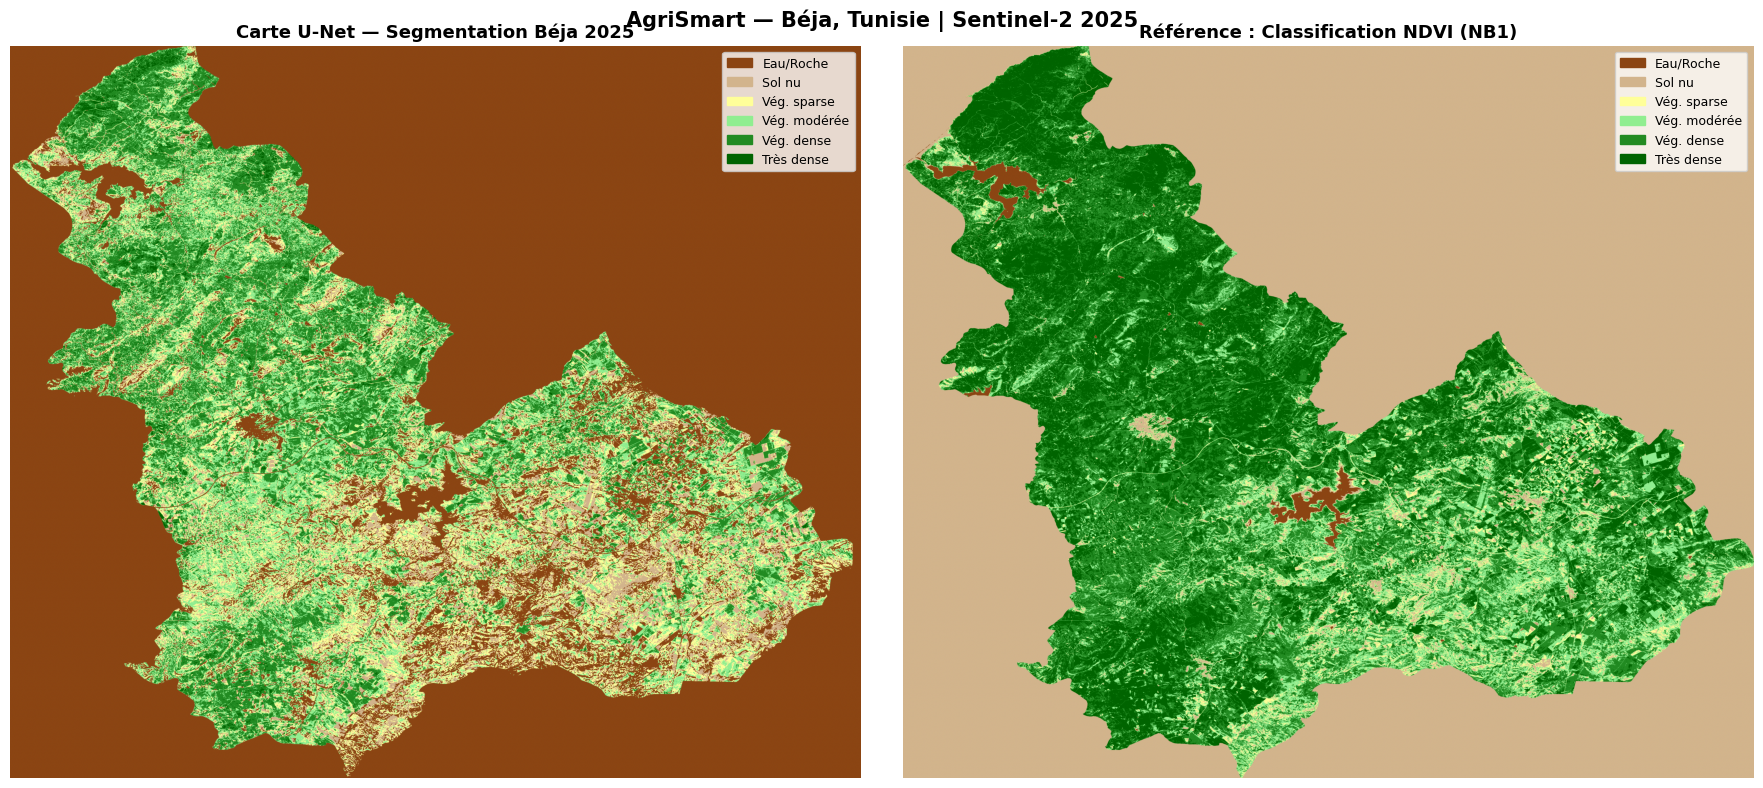


📊 Accord U-Net vs NDVI classification : 1.6%
   (Rapport section 3.3 : accord K-Means/NDVI = 72.3%)


In [26]:
from matplotlib.colors import ListedColormap
import matplotlib.patches as mpatches

cmap = ListedColormap(class_colors)
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Carte prédite
im = axes[0].imshow(pred_map, cmap=cmap, vmin=0, vmax=5)
patches = [mpatches.Patch(color=class_colors[i], label=class_names[i]) for i in range(6)]
axes[0].legend(handles=patches, loc='upper right', fontsize=9)
axes[0].set_title('Carte U-Net — Segmentation Béja 2025', fontsize=13, fontweight='bold')
axes[0].axis('off')

# Comparaison NDVI classification (NB1)
ndvi_cls = np.load(TEMP_DIR / 'ndvi_classes.npy')
axes[1].imshow(ndvi_cls, cmap=cmap, vmin=0, vmax=5)
axes[1].legend(handles=patches, loc='upper right', fontsize=9)
axes[1].set_title('Référence : Classification NDVI (NB1)', fontsize=13, fontweight='bold')
axes[1].axis('off')

plt.suptitle('AgriSmart — Béja, Tunisie | Sentinel-2 2025', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'NB4_segmentation_map.png', dpi=150, bbox_inches='tight')
plt.show()

# Accord entre U-Net et NDVI classification
agreement = np.mean(pred_map == ndvi_cls) * 100
print(f'\n📊 Accord U-Net vs NDVI classification : {agreement:.1f}%')
print('   (Rapport section 3.3 : accord K-Means/NDVI = 72.3%)')

---
## 💾 Part 7 : Export GeoTIFF géoréférencé (compatible QGIS)

In [27]:
print('💾 Export GeoTIFF géoréférencé...')

output_tiff = OUTPUT_DIR / 'unet_segmentation_beja_2025.tif'

with rasterio.open(output_tiff, 'w', **meta) as dst:
    dst.write(pred_map, 1)

    # Métadonnées utiles
    dst.update_tags(
        project='AgriSmart',
        region='Béja, Tunisie',
        model='U-Net + MobileNetV2',
        training_epochs=str(checkpoint['epoch']),
        val_accuracy=f"{checkpoint['val_acc']*100:.1f}%",
        source='Sentinel-2 S2_SR_HARMONIZED 2025',
        classes='0=Eau/Roche,1=Sol_nu,2=Veg_sparse,3=Veg_modérée,4=Veg_dense,5=Très_dense'
    )

size_mb = output_tiff.stat().st_size / 1e6
print(f'✅ GeoTIFF exporté : {output_tiff}')
print(f'   Taille : {size_mb:.1f} MB')
print(f'   CRS    : {meta["crs"]}')
print('\n📌 Ce fichier peut être ouvert directement dans QGIS')
print('   Les classes sont encodées en uint8 (0-5)')

💾 Export GeoTIFF géoréférencé...
✅ GeoTIFF exporté : /content/drive/MyDrive/agrismart_outputs/unet_segmentation_beja_2025.tif
   Taille : 24.8 MB
   CRS    : EPSG:4326

📌 Ce fichier peut être ouvert directement dans QGIS
   Les classes sont encodées en uint8 (0-5)


---
## ✅ Part 8 : Résumé des fichiers produits

**→ Prêt pour NB5 : Validation & Error Analysis**

In [28]:
print('=== RÉSUMÉ NB4 ===')
print(f'Carte prédite     : {W}×{H} pixels')
print(f'Accord U-Net/NDVI : {agreement:.1f}%')
print()
print('Fichiers produits dans agrismart_outputs/ :')
for f in sorted(OUTPUT_DIR.iterdir()):
    print(f'   {f.name}  ({f.stat().st_size/1e3:.0f} KB)')
print('\n✅ NB4 terminé → lancer NB5_validation.ipynb')

=== RÉSUMÉ NB4 ===
Carte prédite     : 5365×4619 pixels
Accord U-Net/NDVI : 1.6%

Fichiers produits dans agrismart_outputs/ :
   NB4_segmentation_map.png  (4194 KB)
   prediction_statistics.csv  (0 KB)
   unet_segmentation_beja_2025.tif  (24838 KB)

✅ NB4 terminé → lancer NB5_validation.ipynb
